!python -m pip install --upgrade pip

!pip install git+https://github.com/facebookresearch/segment-anything.git

In [1]:
#visualization
import matplotlib.pyplot as plt
import cv2

#model
import torch
from segment_anything import sam_model_registry
from segment_anything import SamAutomaticMaskGenerator
import supervision as sv

In [2]:
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
MODEL_TYPE = "vit_h"
CHECKPOINT_PATH = "./src/model/sam_vit_h_4b8939.pth"

In [3]:
sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH)
sam.to(device=DEVICE);

In [9]:
IMAGE_PATH = "./src/images/x004.jpeg"
image_bgr = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

In [10]:
mask_generator = SamAutomaticMaskGenerator(sam)
result = mask_generator.generate(image_rgb)

In [11]:
mask_annotator = sv.MaskAnnotator(color_lookup=sv.ColorLookup.INDEX)
detections = sv.Detections.from_sam(result)
annotated_image = mask_annotator.annotate(image_bgr.copy(), detections)

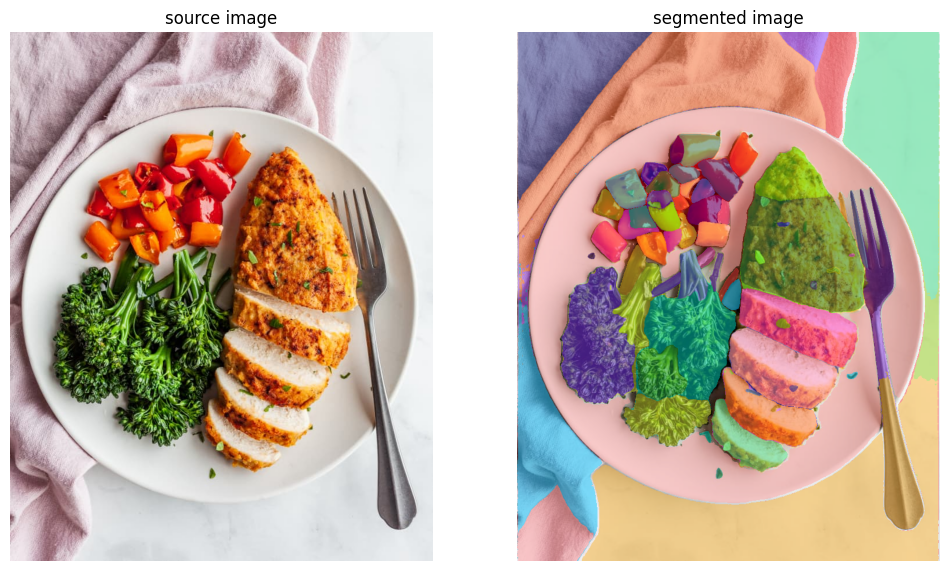

In [12]:
sv.plot_images_grid(
    images=[image_bgr, annotated_image],
    grid_size=(1, 2),
    titles=['source image', 'segmented image']
)

In [15]:
masks = [
    mask['segmentation']
    for mask
    in sorted(result, key=lambda x: x['area'], reverse=True)
]

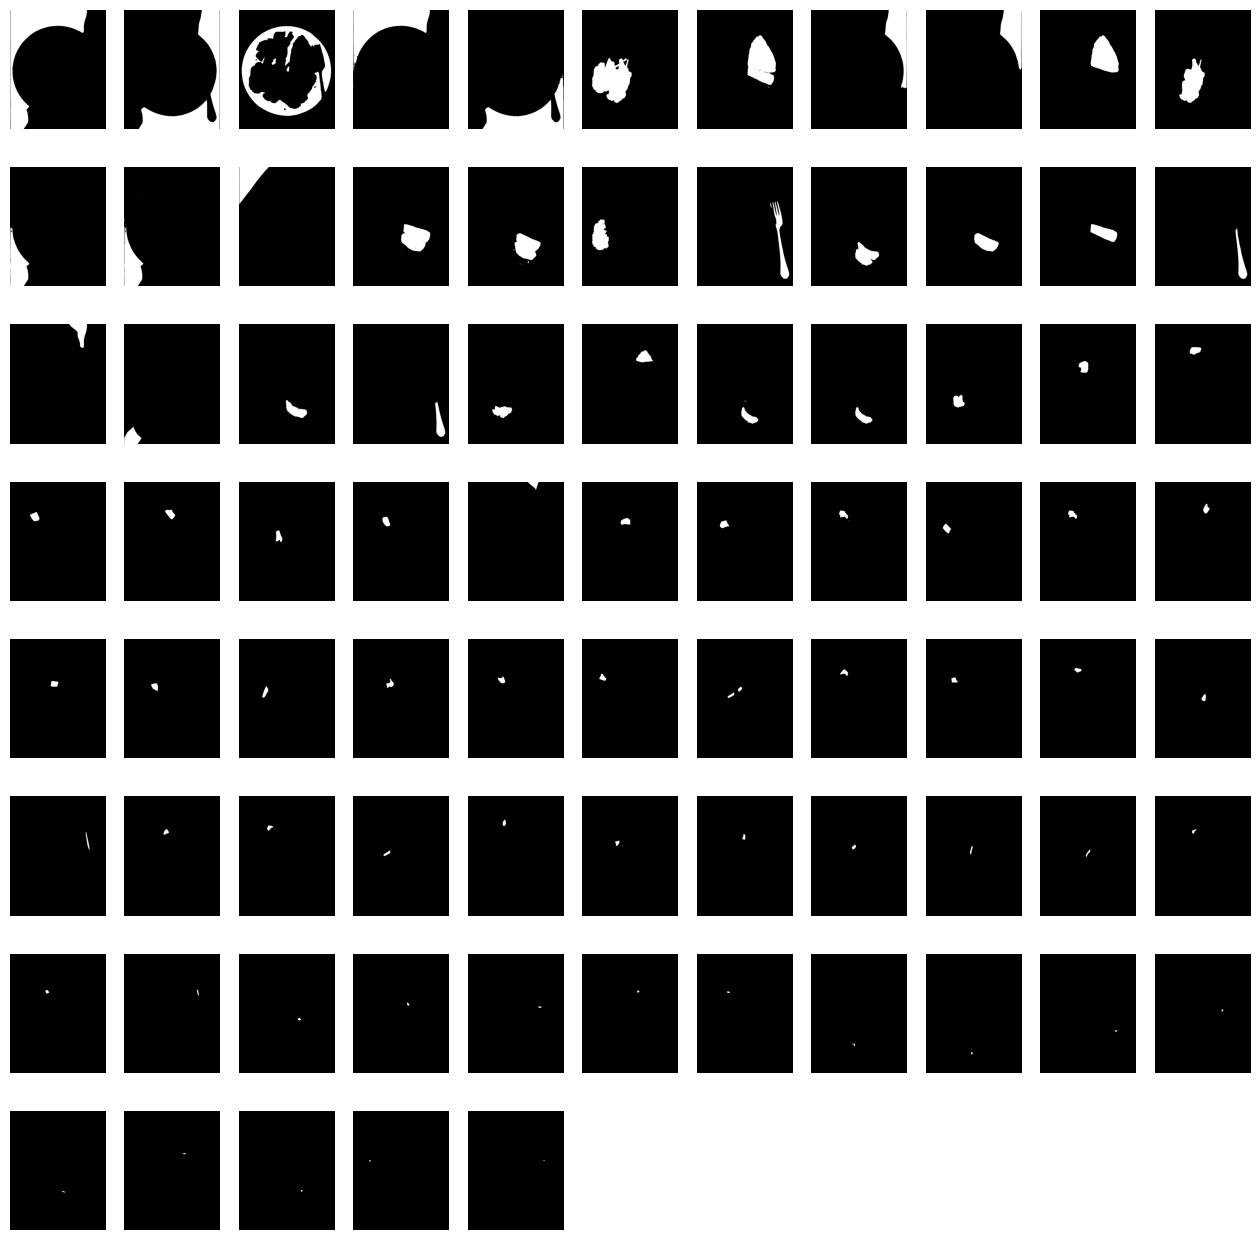

In [20]:
sv.plot_images_grid(
    images=masks,
    grid_size=(8, int(len(masks)//8+1)),
    size=(16, 16)
)